# Étude complète d’un matériau cristallin
Notebook structuré selon les consignes du projet.

Remplacer `MATERIAL_NAME` par le matériau attribué.

## 1. Téléchargement de la structure cristalline

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pymatgen as mg

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter

#import pymatviz as pv
# Exemple avec pymatgen (Materials Project)
#from mp_api.client import MPRester
from pymatgen.ext.matproj import MPRester  #j'ai mis celui l'autre import ne marche sur mon vscode 
from mp_api.client import MPRester
API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"  # Remplacer par l'ID réel

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(material_id)

structure

Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<00:00, 505.22it/s]


Structure Summary
Lattice
    abc : 3.591529777348829 4.011704109915074 4.011704492667927
 angles : 73.52458272493287 63.408171496645096 63.40816766642372
 volume : 45.96833740475323
      A : np.float64(3.20947838) np.float64(0.0) np.float64(1.61193507)
      B : np.float64(1.4266634900000001) np.float64(3.56532885) np.float64(1.16053063)
      C : np.float64(-0.0052797) np.float64(-0.023513299999999) np.float64(4.01163211)
    pbc : True True True
PeriodicSite: Li (3.492, 2.618, 5.05) [0.7607, 0.7393, 0.7393]
PeriodicSite: Li (1.139, 0.9233, 1.734) [0.2393, 0.2607, 0.2607]
PeriodicSite: C (1.24, 3.098, 1.532) [0.0, 0.8697, 0.1303]
PeriodicSite: C (0.1812, 0.444, 3.64) [-0.0, 0.1303, 0.8697]

## 2. Réseau direct et réciproque

In [2]:
import numpy as np

lattice = structure.lattice
a1, a2, a3 = lattice.matrix
reciprocal_lattice = lattice.reciprocal_lattice.matrix

print("Vecteurs réseau direct:")
print(a1, a2, a3)

print("Vecteurs réseau réciproque:")
print(reciprocal_lattice)

# #représentation des réseaux
# # reseau direct
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# # Origine
# origin = [0, 0, 0]

# # Tracé des vecteurs
# ax.quiver(*origin, *a1, length=1, normalize=False)
# ax.quiver(*origin, *a2, length=1, normalize=False)
# ax.quiver(*origin, *a3, length=1, normalize=False)

# # Labels
# ax.text(*a1, "a1")
# ax.text(*a2, "a2")
# ax.text(*a3, "a3")

# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# plt.show()

# # reseau reciproque
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# # Tracé des vecteurs
# ax.quiver(*origin, *reciprocal_lattice[0], length=1, normalize=False)
# ax.quiver(*origin, *reciprocal_lattice[1], length=1, normalize=False)
# ax.quiver(*origin, *reciprocal_lattice[2], length=1, normalize=False)

# # Labels
# ax.text(*reciprocal_lattice[0], "b1")
# ax.text(*reciprocal_lattice[1], "b2")
# ax.text(*reciprocal_lattice[2], "b3")

# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# plt.show()


Vecteurs réseau direct:
[3.20947838 0.         1.61193507] [1.42666349 3.56532885 1.16053063] [-0.0052797  -0.0235133   4.01163211]
Vecteurs réseau réciproque:
[[ 1.95870735 -0.78312019 -0.00201224]
 [-0.00518063  1.76101721  0.010315  ]
 [-0.78553983 -0.19477746  1.56406616]]


## 3. Type de maille, système cristallin, groupe ponctuel

In [3]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

sga = SpacegroupAnalyzer(structure)

print("Système cristallin:", sga.get_crystal_system())
print("Type de maille:", sga.get_lattice_type())
print("Groupe ponctuel:", sga.get_point_group_symbol())

Système cristallin: orthorhombic
Type de maille: orthorhombic
Groupe ponctuel: mmm


## 4. Application de trois éléments de symétrie

In [4]:
# Exemple d'opérations de symétrie
sym_ops = sga.get_symmetry_operations()

sym_ops_no_identity = [
    op for op in sym_ops
    if not (np.allclose(op.rotation_matrix, np.eye(3), atol=1e-5) and
            np.allclose(op.translation_vector, 0, atol=1e-5))
]
# c'est quel atome ? 
for i in range(5,8):
    print("Matrice de rotation:")
    print(sym_ops_no_identity[i].rotation_matrix)
    print("Vecteur de translation:")
    print(sym_ops_no_identity[i].translation_vector)


Matrice de rotation:
[[ 1.  1.  1.]
 [ 0.  0. -1.]
 [ 0. -1.  0.]]
Vecteur de translation:
[0. 0. 0.]
Matrice de rotation:
[[ 1.  1.  1.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Vecteur de translation:
[0. 0. 0.]
Matrice de rotation:
[[ 1.  1.  1.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Vecteur de translation:
[0. 0. 0.]


## 5. Visualisation de la zone de Brillouin

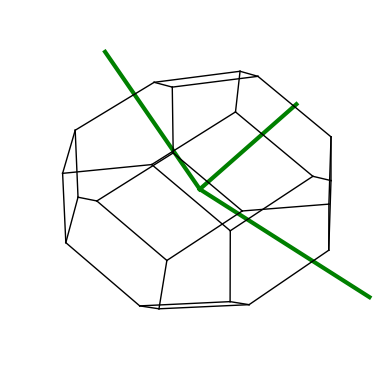

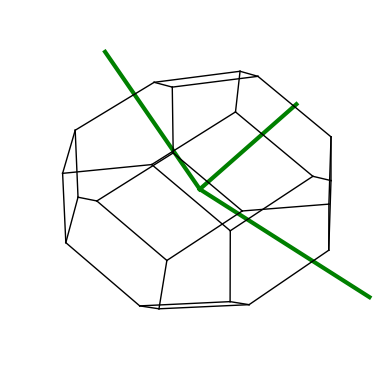

In [5]:
from pymatgen.electronic_structure.plotter import plot_brillouin_zone

plot_brillouin_zone(lattice.reciprocal_lattice)

## 6. Diffractogramme (Cu Kα, λ=1.54060 Å)

In [ ]:
from pymatgen.analysis.diffraction.xrd import XRDCalculator

wavelength = 1.54060
xrd = XRDCalculator(wavelength=wavelength)
pattern = xrd.get_pattern(structure)

#Il faut pas oublier le graphs avec les trois pics ;) 
pattern

DiffractionPattern
$2\Theta$: [24.93668248 29.97559841 31.07029778 33.59645178 37.42575522 46.41022204
 46.4102359  48.6711546  50.80235573 51.16372679 55.06230619 57.39993312
 57.3999434  57.84920675 57.84921966 60.32646944 62.29281469 62.29283115
 63.58831912 64.77722252 70.62059682 70.95619563 70.95620672 73.87264017
 73.87265635 74.98365228 74.98366644 78.18906077 78.18908265 79.14308675
 79.14310136 79.83019358 80.73688891 80.73690146 82.51693099 82.51694201
 82.70056554 82.70057705 82.76359117 82.76360227 83.07733026 87.54674035
 89.45444009 89.45445111]
Intensity: [7.31223152e+01 1.00000000e+02 4.15333972e+00 8.93469134e+00
 3.92693826e+00 4.22593358e+01 1.40864353e+01 2.32573306e-02
 1.61720309e+01 5.27073402e+00 6.03417842e+00 4.85010488e+00
 1.61670081e+00 2.91217875e+00 2.91217609e+00 4.30758719e+00
 3.68674141e-01 3.68673661e-01 1.06978099e+01 1.69686151e+00
 4.83885914e+00 1.39543052e-01 1.39542974e-01 7.02488290e-02
 2.34162700e-02 1.52708324e+00 1.52708221e+00 1.74491301

## 7. Structure de bandes électroniques

In [1]:
# Télécharger la structure de bandes
from mp_api.client import MPRester
from pymatgen.io.cif import CifWriter
from matplotlib import pyplot as plt 
from tabulate import tabulate
from pymatgen.electronic_structure import bandstructure
from pymatgen.electronic_structure import plotter
import numpy as np

m = MPRester("PXBFSqNjWuCbMDn152B5RsMt61dfXOLI")
bandstructure = m.get_bandstructure_by_material_id("mp-1378")

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
#initialisation des données et variables utiles par la suite
plot = plotter.BSPlotter(bandstructure)
# crée un dictionnaire qui contient ce que je veux
data = plot.bs_plot_data()
zero_energy = data.get('zero_energy')
distance = data.get('ticks').get('distance')
labels = data.get('ticks').get('label')
distances = data.get('distances')
energy = data.get('energy')
bandgap = bandstructure.get_band_gap()
vbmData = bandstructure.get_vbm()
cbmData = bandstructure.get_cbm()

Type de energy['1'][0]: <class 'numpy.ndarray'>
Longueur de energy['1'][0]: 20

Type de energy['1'][0][0]: <class 'numpy.ndarray'>
Longueur de energy['1'][0][0]: 27


Text(0.5, 1.0, 'Structure de bandes électroniques du LiC')

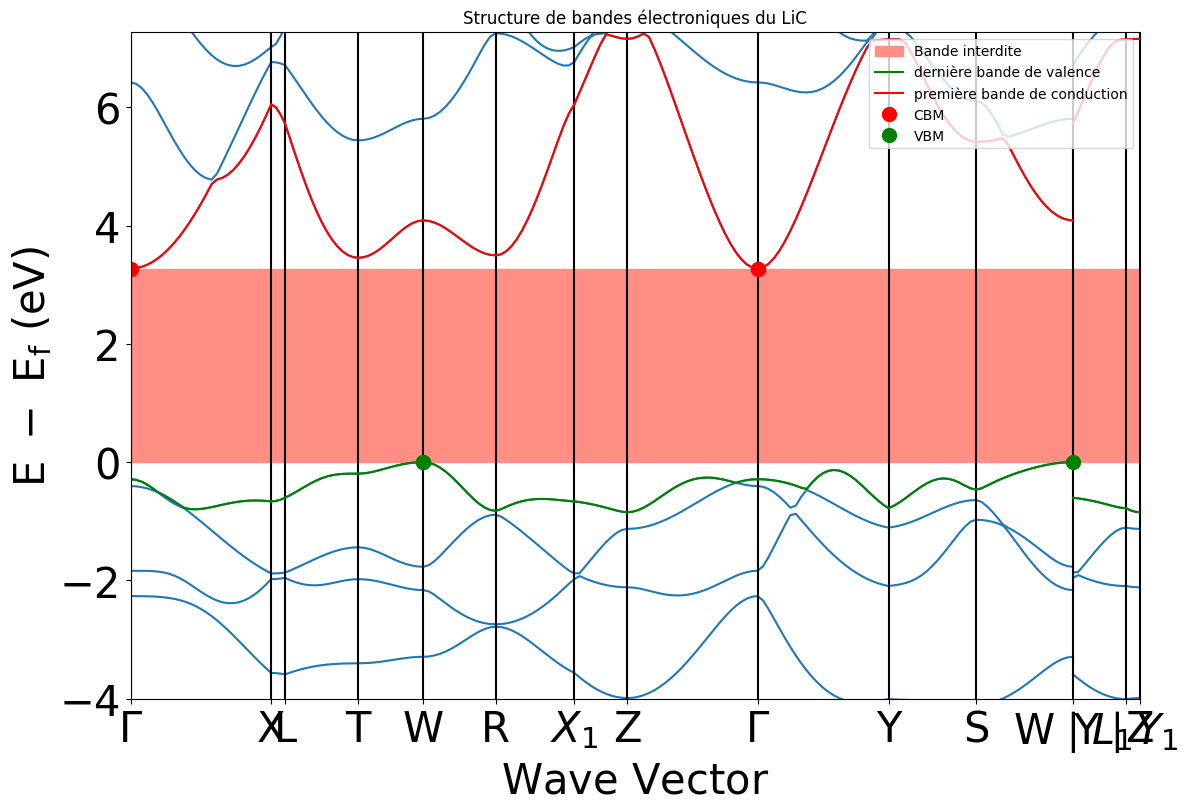

In [5]:
#plot de la structure de bandes

# on remarque que les énergies sont données par rapport à l'énergie de Fermi, d'où le zéro à 0 eV.
# Cela explique aussi pourquoi CBM et VBM sont à des valeurs différentes de sur le graphe , 
# alors qu'elles sont à des énergies positives et négatives respectivement par rapport à l'énergie de Fermi.
# energy est donc : {'1': [segment0, segment1, ..., segment12]}
# Chaque segment est lui-même une liste ou un array

print("Type de energy['1'][0]:", type(energy['1'][0]))
print("Longueur de energy['1'][0]:", len(energy['1'][0]))
print()
print("Type de energy['1'][0][0]:", type(energy['1'][0][0]))
print("Longueur de energy['1'][0][0]:", len(energy['1'][0][0]))
vbm_idx = list(vbmData.get('band_index').values())[0][0]
cbm_idx = list(cbmData.get('band_index').values())[0][0]

plot.get_plot()
plt.fill_between(np.linspace(distance[0],distance[-1],500),
                 0, bandgap.get('energy'), color="#FF8E85", label = "Bande interdite")
#plot la derniere bande de valence en vert et la premiere bande de conduction en rouge
for i in range(len(distances)):
    plt.plot(distances[i], energy['1'][i][vbm_idx], 'g', label = "dernière bande de valence" if i == 0 else "")
    plt.plot(distances[i], energy['1'][i][cbm_idx], 'r', label = "première bande de conduction" if i == 0 else "")
#plot les points du VBM en vert et du CBM en rouge
cbms = data.get('cbm')
for i in range(len(cbms)):
    (a, b) = cbms[i]
    plt.plot(a, b, 'or', markersize=10, label = "CBM" if i == 0 else "")

vbms = data.get('vbm')
for i in range(len(vbms)):
    (a, b) = vbms[i]
    plt.plot(a, b, 'og', markersize=10, label = "VBM" if i == 0 else "")
#legende
plt.legend(loc = "upper right")
plt.title("Structure de bandes électroniques du LiC")

## 8. Analyse de la structure de bandes: dispersions

In [6]:
#calcule la pente sur l'intervalle (x,y)
#renvoit un tableau pour un affichage pratique des flèches : 
#    pour chaque intervalle entre 2 kpoints : [pente,x_0,y_0,dx,dy]
def slope(x,y):
	return np.array([abs((y[-1]-y[0])/(x[-1]-x[0])),x[0],y[0],x[-1]-x[0],y[-1]-y[0]])

#calcule la dispersions maximale et minimale de la bande y
#retourne : s=tableau des résultats retournés par slope pour chaque intervalle de kpoints
#           l'indice de la pente maximale dans s
#           l'indice de la pente minimale dans s
def computeDispersions_filtered(y, emin=-1.0, emax=1.0):
    """
    Calcule les dispersions uniquement sur les segments
    où la bande reste dans la fenêtre [emin, emax] eV
    """
    slopes = []
    indices = []
    for i in range(len(distances)):
        e = energy['1'][i][y]
        # On garde le segment seulement si toute la bande
        # reste dans la fenêtre d'énergie
        if np.min(e) >= emin and np.max(e) <= emax:
            slopes.append(slope(distances[i], e))
            indices.append(i)
    
    if not slopes:
        print("Aucun segment trouvé dans la fenêtre d'énergie !")
        return None, None, None
    
    slopes = np.array(slopes).T
    # print(f"Segments retenus : {indices}")
    # for k, idx in enumerate(indices):
    #     print(f"  Segment {idx} ({labels[idx]}→{labels[idx+1]}) : pente = {slopes[0,k]:.4f} eV/Å")
    
    return (slopes, indices[np.argmax(slopes[0])], indices[np.argmin(slopes[0])])

(vbs, maxVb, minVb) = computeDispersions_filtered(vbm_idx, emin=-1.0, emax=0.1)
(cbs, maxCb, minCb) = computeDispersions_filtered(cbm_idx, emin=3.0,  emax=7.0)



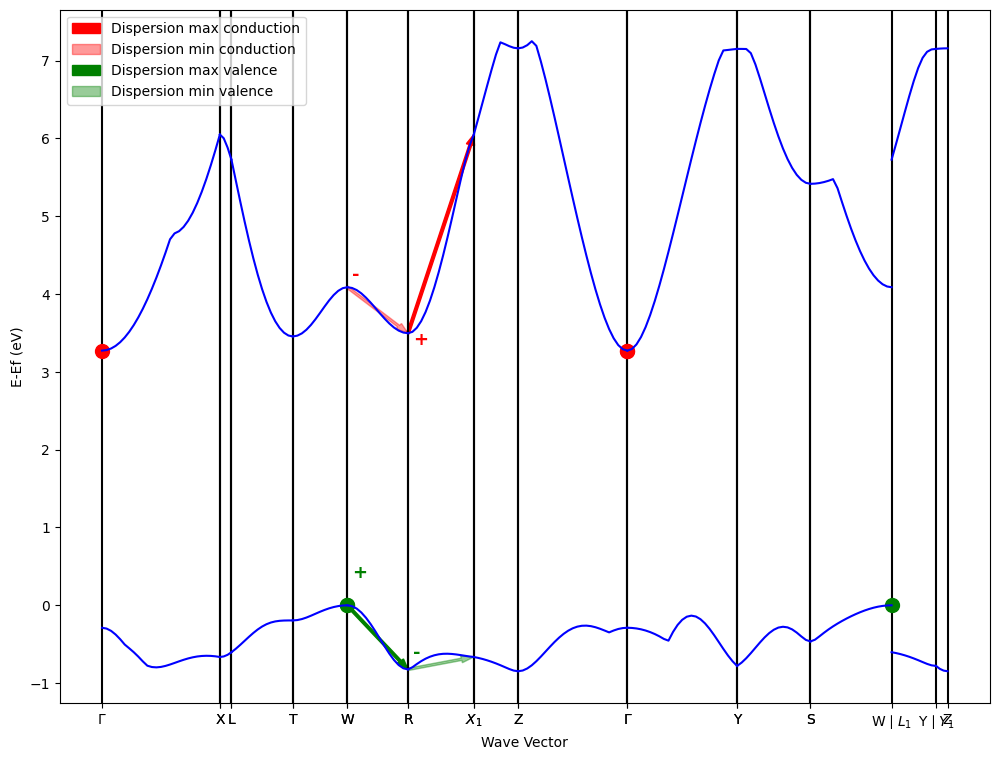

In [7]:
# affichage des endroits de dispersion maximale et minimale pour les bandes de valence et de conduction



# print("=== Bande de conduction : min/max par segment ===")
# for i in range(len(distances)):
#     e = energy['1'][i][cbm_idx]
#     print(f"  Segment {i} ({labels[i]}→{labels[i+1]}) : "
#           f"min={np.min(e):.3f} eV, max={np.max(e):.3f} eV, "
#           f"pente={abs(e[-1]-e[0])/(distances[i][-1]-distances[i][0]):.3f} eV/Å")
vbm_points = data.get('vbm')
cbm_points = data.get('cbm')
fig,ax = plt.subplots(1,1,figsize=(12,9))
for i in range(len(distance)):
    plt.axvline(distance[i],0,color="black")
    
for i in range(len(vbm_points)):
    (a,b) = vbm_points[i]
    plt.plot(a,b,'og',markersize=10)
for i in range(len(cbm_points)):
    (a,b) = cbm_points[i]
    plt.plot(a,b,'or',markersize=10)
    
for i in range(len(distances)):
    plt.plot(distances[i],energy['1'][i][vbm_idx],'b')
    plt.plot(distances[i],energy['1'][i][cbm_idx],'b')

ax.set_xticks(distance)
ax.set_xticklabels(labels)
ax.set_xlabel('Wave Vector')
ax.set_ylabel('E-Ef (eV)')

# maxVb, minVb, maxCb, minCb sont maintenant des indices de segments
# On recalcule les données de la flèche directement depuis le segment
def get_arrow(seg_idx, band_idx):
    x0 = distances[seg_idx][0]
    y0 = energy['1'][seg_idx][band_idx][0]
    dx = distances[seg_idx][-1] - x0
    dy = energy['1'][seg_idx][band_idx][-1] - y0
    return x0, y0, dx, dy

x0,y0,dx,dy = get_arrow(maxCb, cbm_idx)
plt.arrow(x0,y0,dx,dy,color='red',width=0.03,length_includes_head=True, label= "Dispersion max conduction")
x0,y0,dx,dy = get_arrow(minCb, cbm_idx)
plt.arrow(x0,y0,dx,dy,color=('red', 0.4),width=0.03,length_includes_head=True, label= "Dispersion min conduction")
x0,y0,dx,dy = get_arrow(maxVb, vbm_idx)
plt.arrow(x0,y0,dx,dy,color='green',width=0.03,length_includes_head=True, label= "Dispersion max valence")
x0,y0,dx,dy = get_arrow(minVb, vbm_idx)
plt.arrow(x0,y0,dx,dy,color=('green', 0.4),width=0.03,length_includes_head=True, label= "Dispersion min valence")

plt.text(distances[maxCb][0]+0.05, energy['1'][maxCb][cbm_idx][0]-0.15, "+", fontsize=13, fontweight='bold', color='red')
plt.text(distances[minCb][0]+0.05, energy['1'][minCb][cbm_idx][0]+0.1,  "-", fontsize=13, fontweight='bold', color='red')
plt.text(distances[maxVb][0]+0.05, energy['1'][maxVb][vbm_idx][0]+0.35, "+", fontsize=13, fontweight='bold', color='green')
plt.text(distances[minVb][0]+0.05, energy['1'][minVb][vbm_idx][0]+0.15, "-", fontsize=13, fontweight='bold', color='green')

plt.legend(loc = "upper left")
plt.show()

## 9. Masse effective (approximation parabolique)


--------------------------  -------------------------------------------------------------------
Parabole d'approximation :  y(k) = -1.0014724594103093k² + 4.92419792587298k -6.027192048189632
Dérivée seconde :           -2.0029449188206185 eVÅ²
Masse effective :           -3.465555893569862e-30 kg




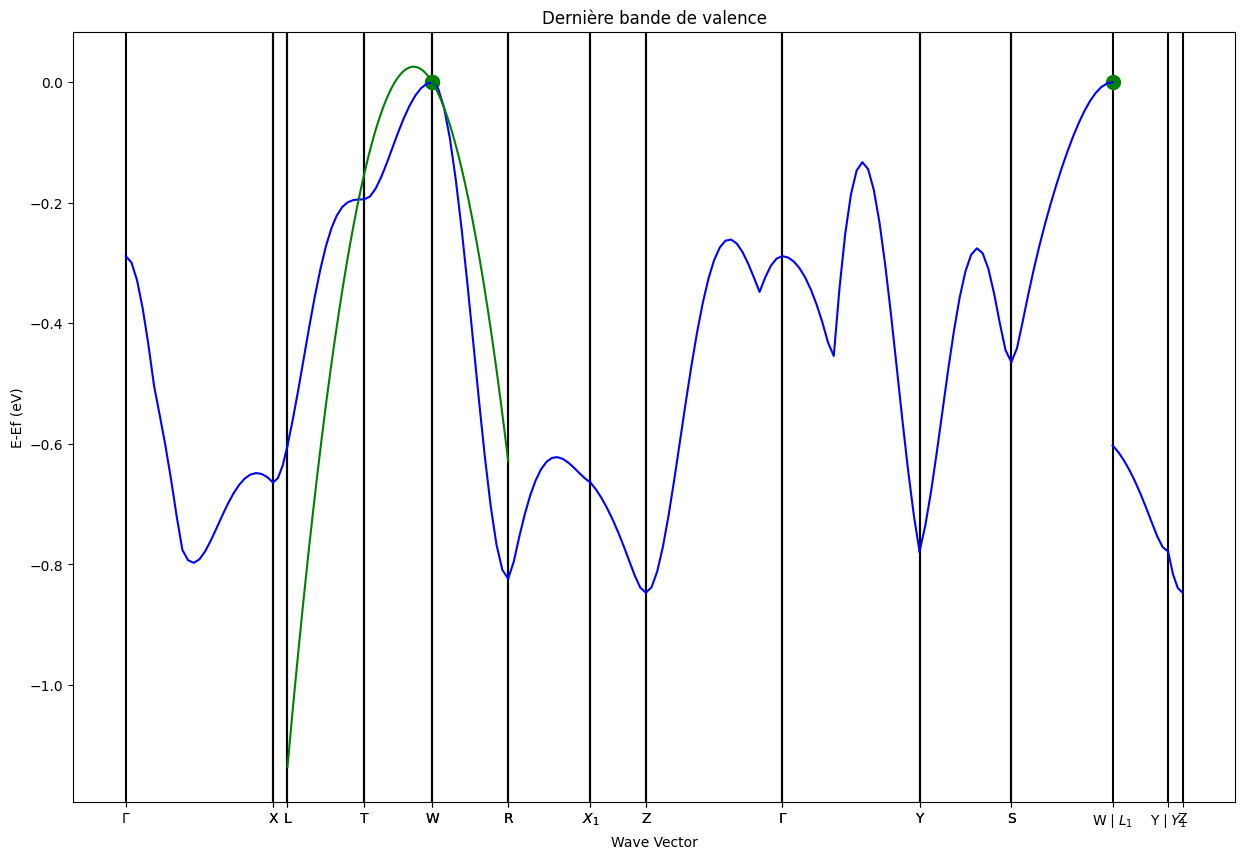

In [8]:
# constantes importantes
hbar2 = ((6.62607004*10**(-34))/(2*np.pi))**2
electronvolt = 1.602176634*10**(-19)
angstrom = 10**(-10)

#plot de la dernière bande de valence et des VBM 
fig,ax = plt.subplots(1,1,figsize=[15,10])
for i in range(len(distance)):
    plt.axvline(distance[i],0,color="black")
for i in range(len(vbm_points)):
    (a,b) = vbm_points[i]
    plt.plot(a,b,'og',markersize=10)
for i in range(len(distances)):
    plt.plot(distances[i],energy['1'][i][vbm_idx],'b')
ax.set_xticks(distance)
ax.set_xticklabels(labels)
ax.set_xlabel('Wave Vector')
ax.set_ylabel('E-Ef (eV)')
plt.title('Dernière bande de valence')

#calcul de la parabole d'approximation aux alentours du VBM
# On cherche le segment contenant le VBM
vbm_k = vbm_points[0][0]  # position k du VBM
vbm_seg = 0
for i in range(len(distances)):
    if distances[i][0] <= vbm_k <= distances[i][-1]:
        vbm_seg = i
        break

seg_prev = max(0, vbm_seg - 1)
seg_next = min(len(distances)-1, vbm_seg + 1)

ks = np.zeros(3)
es = np.zeros(3)
(ks[1],es[1]) = vbm_points[0]
(ks[0],es[0]) = (distances[seg_prev][-2], energy['1'][seg_prev][vbm_idx][-2])
(ks[2],es[2]) = (distances[seg_next][2],  energy['1'][seg_next][vbm_idx][2])
a = np.polyfit(ks,es,2)

#affichage des résultats
# calcul: E(k) approximée par la parabole, E(k) = a[0]k^2 + a[1]k + a[2] donc E''(k) = 2*a[0]
# Masse effective: m* = ħ² / (d²E/dk²) = ħ² / (2*a[0]) (en eV·Å², à convertir en kg)
print(tabulate([["Parabole d'approximation : ","y(k) = "+str(a[0])+"k\u00b2 + "+str(a[1])+"k "+str(a[2])],
                ["Dérivée seconde : ",str(2*a[0])+" eV\u212b\u00b2"],
                ["Masse effective : ",str(hbar2/(2*a[0]*electronvolt*(angstrom)**2))+" kg"]],
                headers=["",""]))
print("\n")
x = np.linspace(distances[seg_prev][0],distances[seg_next][-1],1000)
plt.plot(x,np.polyval(a,x),'g')
plt.show()


--------------------------  ------------------------------------------------------------------
Parabole d'approximation :  y(k) = 7.931331435324315k² -88.92807181875622k +252.54360452229767
Dérivée seconde :           15.86266287064863 eVÅ²
Masse effective :           4.375884190767505e-31 kg




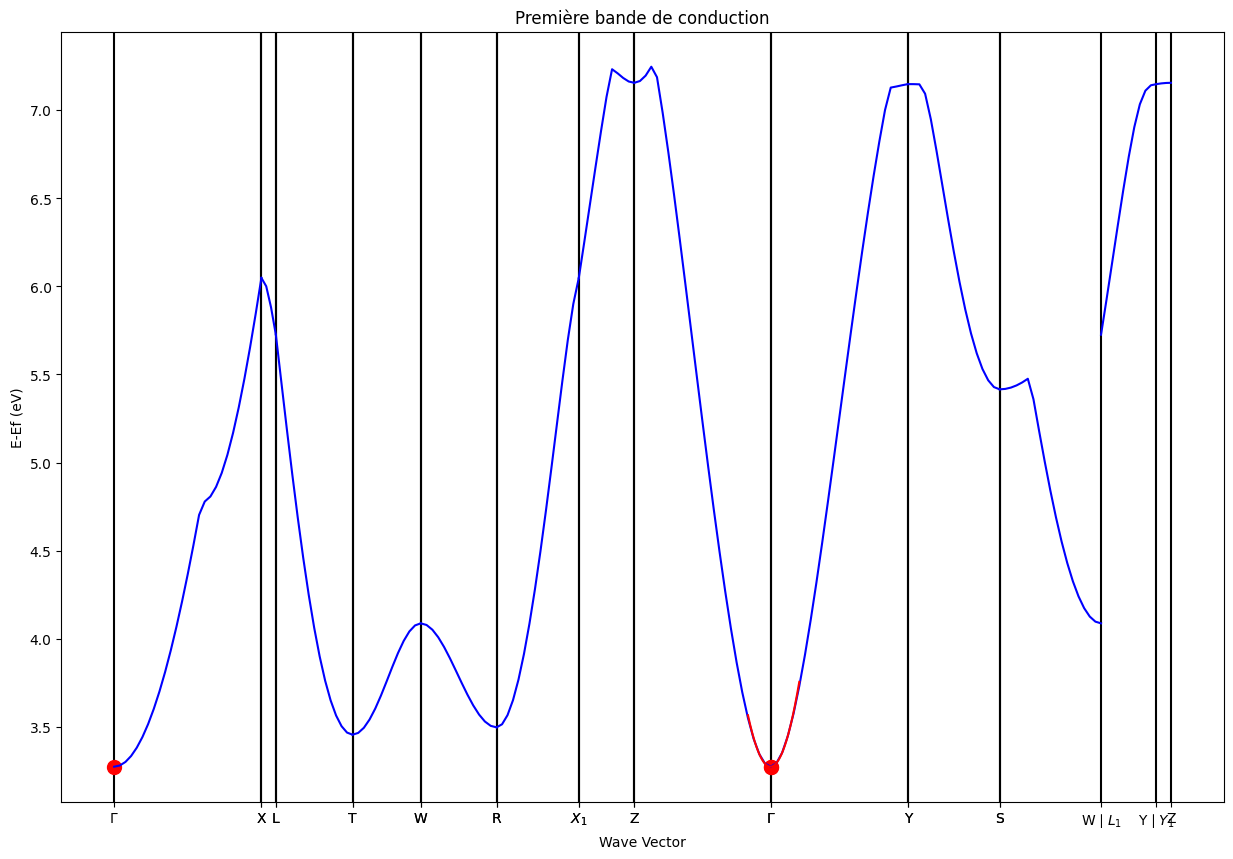

In [9]:
# print("Tous les points CBM:")
# for i, pt in enumerate(cbm_points):
#     print(f"  cbm_points[{i}]: k={pt[0]:.4f}, E={pt[1]:.4f} eV")

#plot de la première bande de conduction et du CBM
fig,ax = plt.subplots(1,1,figsize=[15,10])
for i in range(len(distance)):
    plt.axvline(distance[i],0,color="black")
for i in range(len(cbm_points)):
    (a,b) = cbm_points[i]
    plt.plot(a,b,'or',markersize=10)
for i in range(len(distances)):
    plt.plot(distances[i],energy['1'][i][cbm_idx],'b')
ax.set_xticks(distance)
ax.set_xticklabels(labels)
ax.set_xlabel('Wave Vector')
ax.set_ylabel('E-Ef (eV)')
plt.title('Première bande de conduction')

# CBM en Γ central (k=5.6084), à la jonction des segments 7 et 8
# On prend un point dans le segment 7 (avant Γ) et un dans le segment 8 (après Γ)
ks2 = np.zeros(3)
es2 = np.zeros(3)
(ks2[1], es2[1]) = cbm_points[1]                                        # CBM en Γ
(ks2[0], es2[0]) = (distances[7][-3], energy['1'][7][cbm_idx][-3])      # point avant Γ
(ks2[2], es2[2]) = (distances[8][2],  energy['1'][8][cbm_idx][2])       # point après Γ
a2 = np.polyfit(ks2, es2, 2)

#affichage des résultats
# même calcul que pour la bande de valence, mais pour la conduction
print(tabulate([["Parabole d'approximation : ","y(k) = "+str(a2[0])+"k\u00b2 "+str(a2[1])+"k +"+str(a2[2])],
                ["Dérivée seconde : ",str(2*a2[0])+" eV\u212b\u00b2"],
                ["Masse effective : ",str(hbar2/(2*a2[0]*electronvolt*(angstrom)**2))+" kg"]],
               headers=["",""]))
print("\n")
x2 = np.linspace(distances[7][-5], distances[8][5], 1000)
plt.plot(x2, np.polyval(a2,x2), 'r')
plt.show()

## 10. Structure de bandes de phonons

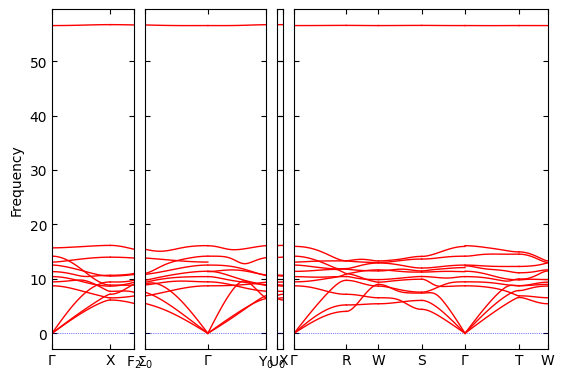

In [2]:
from phonopy import load as phonopy_load
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections
import matplotlib.pyplot as plt

# Charger le fichier (phonopy lit le .xz directement)
phonon = phonopy_load("phonopy_params (2).yaml.xz")

# Tracer automatiquement la structure de bandes
phonon.auto_band_structure(
    plot=True,
    write_yaml=False
)
plt.show()

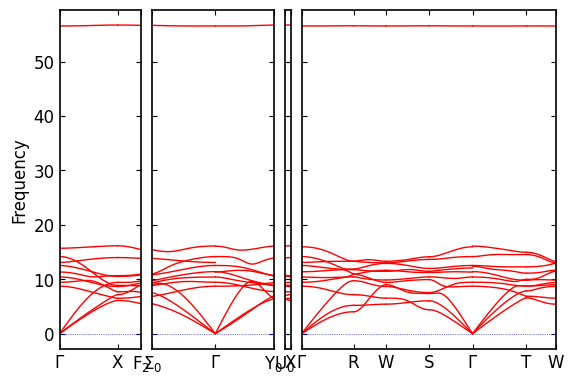

In [10]:
from phonopy import load as phonopy_load
import matplotlib.pyplot as plt

phonon = phonopy_load("phonopy_params (2).yaml.xz")
phonon.auto_band_structure(npoints=101)

# Correction : plot_band_structure() retourne juste un objet plt
plt_obj = phonon.plot_band_structure()

# Récupérer fig et ax depuis matplotlib directement
fig = plt.gcf()
ax = plt.gca()

# Personnalisation
ax.set_ylabel("Frequencies (THz)", fontsize=13)
ax.set_xlabel("Wave Vector", fontsize=13)
ax.set_title("Phonon Band Structure - LiC (mp-1378)", fontsize=14)
ax.set_ylim(0,15)
ax.axhline(y=0, color='k', linewidth=0.8, linestyle='--')

plt.show()

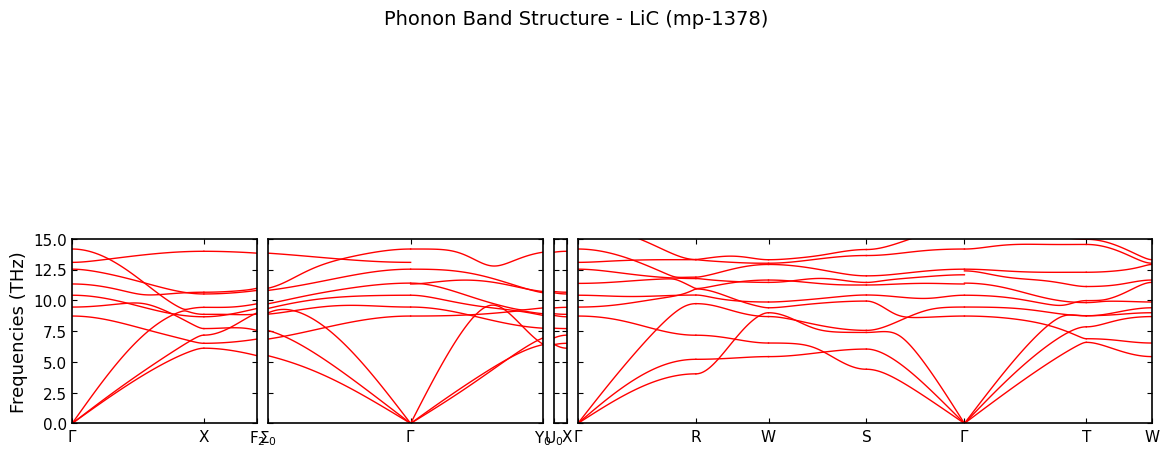

In [13]:
from phonopy import load as phonopy_load
import matplotlib.pyplot as plt

phonon = phonopy_load("phonopy_params (2).yaml.xz")
phonon.auto_band_structure(npoints=101)
phonon.plot_band_structure()

fig = plt.gcf()

# Agrandir la figure
fig.set_size_inches(12, 7)

# Ajuster tous les axes
for ax in fig.get_axes():
    ax.set_ylim(0, 15)
    ax.set_ylabel("Frequencies (THz)", fontsize=13)
    ax.tick_params(axis='both', labelsize=11)

# Supprimer les marges et maximiser l'espace
plt.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.12, wspace=0.05)
fig.suptitle("Phonon Band Structure - LiC (mp-1378)", fontsize=14)

plt.savefig("phonon_LiC.png", dpi=150, bbox_inches='tight')
plt.show()

## 11. Vitesse du son (branches acoustiques)

In [29]:
import numpy as np

def find_acoustic_branches(frequencies, threshold=0.5):
    frequence = []
    branche = []
    zone = []
    
    for i in range(len(frequencies)):  # boucle sur les segments
        n_branches = frequencies[i].shape[1]  # phonopy: (n_qpoints, n_branches)
        
        for j in range(n_branches):  # boucle sur les branches
            # Extraire la branche j du segment i : tous les qpoints
            freq_branch = frequencies[i][:, j]  # ← correction clé : [:, j] au lieu de [j]
            
            # Condition : fréquence quasi-nulle au début OU à la fin du segment
            if (abs(freq_branch[0]) < threshold or abs(freq_branch[-1]) < threshold) \
                and j not in branche and i not in zone:
                zone.append(i)
                branche.append(j)
                frequence.append(freq_branch)
    
    return frequence, branche, zone

acoustic_branches = find_acoustic_branches(frequency)
frequences_acoustiques, indices_branches, indices_zones = acoustic_branches

print("Branches acoustiques :", indices_branches)
print("Zones correspondantes :", indices_zones)

# Récupérer distances et fréquences pour chaque branche acoustique
q1 = distances[indices_zones[0]]
q2 = distances[indices_zones[1]]
q3 = distances[indices_zones[2]]

f1 = frequency[indices_zones[0]][:, indices_branches[0]]
f2 = frequency[indices_zones[1]][:, indices_branches[1]]
f3 = frequency[indices_zones[2]][:, indices_branches[2]]

Branches acoustiques : [0, 1, 2]
Zones correspondantes : [0, 2, 3]


In [26]:
import numpy as np

def get_segment_names(labels, path_connections):
    segment_names = []
    label_idx = 0
    
    for i, connected in enumerate(path_connections):
        start = labels[label_idx]
        end   = labels[label_idx + 1]
        segment_names.append(f"{start}-{end}")
        
        if connected:
            label_idx += 1
        else:
            label_idx += 2
    
    return segment_names

def find_acoustic_branches(frequencies, distances, segment_names, threshold=0.5):
    frequence = []
    branche   = []
    zone      = []
    noms      = []

    for i in range(len(frequencies)):
        n_branches = frequencies[i].shape[1]

        for j in range(n_branches):
            freq_branch = frequencies[i][:, j]

            if (abs(freq_branch[0]) < threshold or abs(freq_branch[-1]) < threshold) \
                and j not in branche and i not in zone:
                zone.append(i)
                branche.append(j)
                frequence.append(freq_branch)
                noms.append(segment_names[i])

    return frequence, branche, zone, noms

segment_names = get_segment_names(labels, connections)

frequences_acoustiques, indices_branches, indices_zones, noms_segments = \
    find_acoustic_branches(frequency, distances, segment_names)

print("Branches acoustiques :", indices_branches)
print("Zones correspondantes :", indices_zones)
print("Ceci correspond aux bandes", ", ".join(noms_segments))


Branches acoustiques : [0, 1, 2]
Zones correspondantes : [0, 2, 3]
Ceci correspond aux bandes $\Gamma$-$\mathrm{X}$, $\Sigma_0$-$\Gamma$, $\Gamma$-$\mathrm{Y_0}$


## 12. Densité d'états de phonons

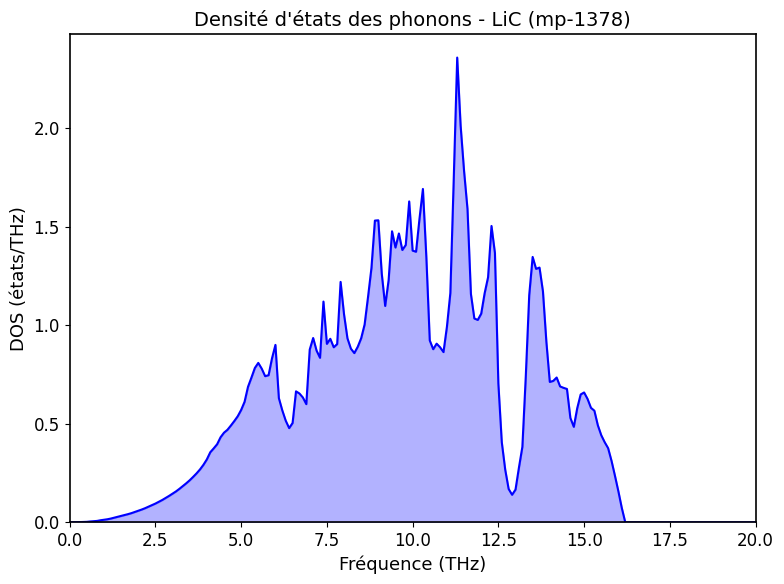

In [34]:


phonon = phonopy_load("phonopy_params (2).yaml.xz")

# Méthode tétraèdre — plus stable que la méthode gaussienne
phonon.run_mesh(
    [20, 20, 20],
    is_mesh_symmetry=False,
    with_eigenvectors=False,
    is_gamma_center=True
)

phonon.run_total_dos(
    use_tetrahedron_method=True,   # ← remplace sigma
    freq_min=0.0,
    freq_max=20.0,
    freq_pitch=0.1
)

# Récupérer les données
dos_dict        = phonon.get_total_dos_dict()
frequencies_dos = dos_dict["frequency_points"]
dos             = dos_dict["total_dos"]

# Tracer
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(frequencies_dos, dos, color='blue', linewidth=1.5)
ax.fill_between(frequencies_dos, dos, alpha=0.3, color='blue')
ax.set_xlabel("Fréquence (THz)", fontsize=13)
ax.set_ylabel("DOS (états/THz)", fontsize=13)
ax.set_title("Densité d'états des phonons - LiC (mp-1378)", fontsize=14)
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 13. Modèles de Debye et d'Einstein

In [ ]:
# Ajustement moindres carrés pour ΘD et ΘE
# Implémentation à compléter

## 14. Courbes de chaleur spécifique

In [ ]:


# Tracer les trois courbes ici

plt.show()